# Opioid Use, Severity, and Treatment Utilization in NSDUH 2024

## Project Goal
This project analyzes NSDUH 2024 data to explore past-year opioid use, opioid use disorder severity, treatment utilization, and medication-related treatment indicators such as buprenorphine and methadone.

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt

In [2]:
file_path = "NSDUH_2024_Tab.txt"

print("File exists:", os.path.exists(file_path))
print("File size (bytes):", os.path.getsize(file_path))

File exists: True
File size (bytes): 390147105


In [3]:
df = pd.read_csv(file_path, sep="\t", low_memory=False)
print(df.shape)

(58633, 2632)


In [4]:
df.head()

,QUESTID2,FILEDATE,ANALWT2_C,VESTR_C,VEREP,PDEN10,COUTYP4,MAIIN102,AIIND102,AGE3,...,ANYNEDYR,FPIMFANYYR2,FPIMFNMYR,OPIIMFNMYR2,OPIIMFNMMN2,ILIMFOTHFG,ILIMFOTHYR,ILIMFOTHMN,LANGVER,GQTYPE2
0,10000616,10/03/2025,1922.385971,40049,2,1,1,2,2,7,...,0.0,0,0,0,0,0,0,0,1,NaN
1,10001334,10/03/2025,546.325998,40037,2,2,2,2,2,1,...,0.0,0,0,0,0,0,0,0,1,NaN
2,10001751,10/03/2025,342.195549,40047,1,2,1,2,2,3,...,0.0,0,0,0,0,1,0,0,1,NaN
3,10002171,10/03/2025,335.358722,40036,1,2,2,2,2,4,...,0.0,0,0,0,0,1,0,0,1,NaN
4,10003462,10/03/2025,1941.603587,40047,1,2,2,2,2,3,...,0.0,0,0,0,0,0,0,0,1,NaN


## Variables Used
This analysis focuses on opioid-related use, opioid use disorder severity, treatment utilization, and medication indicators.

Key variables:
- `OPIANYYR2`: past-year opioid use
- `SVYROPIANY2`: opioid use disorder severity
- `SUTOPOPIPY2`: opioid-related treatment in past year
- `RXBUPRANY2`: buprenorphine-related indicator
- `RXMTDNANY2`: methadone-related indicator
- `CATAGE`: age category
- `IRSEX`: sex

In [5]:
candidate_cols = [
    "QUESTID2",
    "CATAGE",
    "IRSEX",
    "NEWRACE2",
    "EDUHIGHCAT",
    "OPIANYYR2",
    "OPINMYR2",
    "OPINMMON2",
    "HERYR",
    "HERMON",
    "UD5OPIANY2",
    "SVYROPIANY2",
    "SUTOPOPIPY2",
    "SUTOPHERPY2",
    "SUTRTDRGPY2",
    "SUTRTPY2",
    "RXBUPRANY2",
    "RXMTDNANY2",
]

existing_cols = [c for c in candidate_cols if c in df.columns]
print(existing_cols)

['QUESTID2', 'CATAGE', 'IRSEX', 'NEWRACE2', 'EDUHIGHCAT', 'OPIANYYR2', 'OPINMYR2', 'OPINMMON2', 'HERYR', 'HERMON', 'UD5OPIANY2', 'SVYROPIANY2', 'SUTOPOPIPY2', 'SUTOPHERPY2', 'SUTRTDRGPY2', 'SUTRTPY2', 'RXBUPRANY2', 'RXMTDNANY2']


In [6]:
df[existing_cols].head()

,QUESTID2,CATAGE,IRSEX,NEWRACE2,EDUHIGHCAT,OPIANYYR2,OPINMYR2,OPINMMON2,HERYR,HERMON,UD5OPIANY2,SVYROPIANY2,SUTOPOPIPY2,SUTOPHERPY2,SUTRTDRGPY2,SUTRTPY2,RXBUPRANY2,RXMTDNANY2
0,10000616,3,2,1,4,0,0,0,0,0,0,4,0,0,0,0,0.0,0.0
1,10001334,1,1,3,5,1,0,0,0,0,0,4,0,0,0,0,0.0,0.0
2,10001751,1,2,1,5,1,0,0,0,0,0,4,0,0,0,0,1.0,0.0
3,10002171,2,2,1,2,0,0,0,0,0,0,4,0,0,0,0,0.0,0.0
4,10003462,1,2,2,5,0,0,0,0,0,0,4,0,0,0,0,0.0,0.0


In [7]:
for col in existing_cols:
    print("\n", col)
    print(df[col].value_counts(dropna=False).head(20))


 QUESTID2
QUESTID2
10000616    1
10001334    1
10001751    1
10002171    1
10003462    1
10004278    1
10004548    1
10004667    1
10004965    1
10005213    1
10006193    1
10006483    1
10006788    1
10006815    1
10007570    1
10007614    1
10008037    1
10008605    1
10008613    1
10009752    1
Name: count, dtype: int64

 CATAGE
CATAGE
4    23542
2    14136
1    11334
3     9621
Name: count, dtype: int64

 IRSEX
IRSEX
2    31531
1    27102
Name: count, dtype: int64

 NEWRACE2
NEWRACE2
1    32185
7    12157
2     7352
6     2826
5     2688
3     1123
4      302
Name: count, dtype: int64

 EDUHIGHCAT
EDUHIGHCAT
4    15961
3    13476
2    12893
5    11334
1     4969
Name: count, dtype: int64

 OPIANYYR2
OPIANYYR2
0    47787
1    10846
Name: count, dtype: int64

 OPINMYR2
OPINMYR2
0    56976
1     1657
Name: count, dtype: int64

 OPINMMON2
OPINMMON2
0    58160
1      473
Name: count, dtype: int64

 HERYR
HERYR
0    58496
1      137
Name: count, dtype: int64

 HERMON
HERMON
0    58558
1

## Filter to Past-Year Opioid Users
The primary analysis focuses on respondents with past-year opioid use.

In [8]:
df_opioid = df[df["OPIANYYR2"] == 1].copy()
print(df_opioid.shape)

(10846, 2632)


## Severity Distribution
This section examines the distribution of opioid use disorder severity among past-year opioid users.

In [9]:
df_opioid["SVYROPIANY2"].value_counts(normalize=True)

SVYROPIANY2
4    0.913148
1    0.052554
3    0.020376
2    0.013922
Name: proportion, dtype: float64

In [10]:
severity_map = {
    1: "Mild",
    2: "Severe",
    3: "Moderate",
    4: "No disorder",
}

df_opioid["SeverityLabel"] = df_opioid["SVYROPIANY2"].map(severity_map)
df_opioid["SeverityLabel"].value_counts()

SeverityLabel
No disorder    9904
Mild            570
Moderate        221
Severe          151
Name: count, dtype: int64

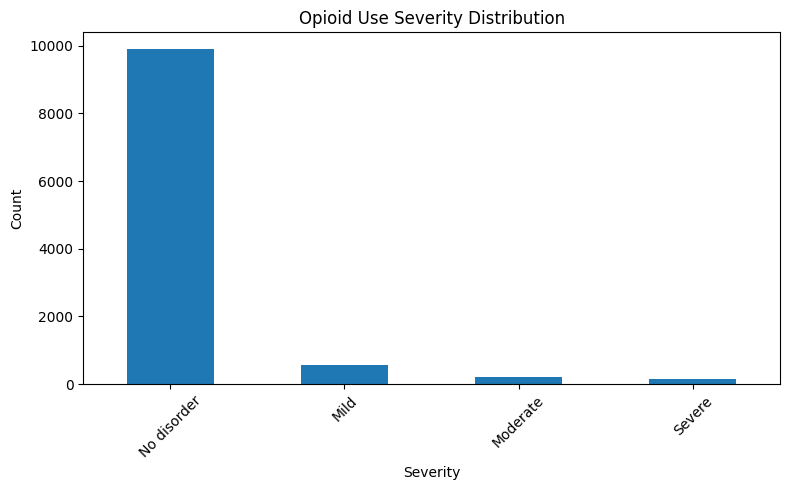

In [11]:
severity_counts = df_opioid["SeverityLabel"].value_counts()
severity_counts = severity_counts.reindex(["No disorder", "Mild", "Moderate", "Severe"])

plt.figure(figsize=(8, 5))
severity_counts.plot(kind="bar")
plt.title("Opioid Use Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Treatment Utilization
This section looks at opioid-related treatment among past-year opioid users.

In [12]:
df_opioid["SUTOPOPIPY2"].value_counts(normalize=True)

SUTOPOPIPY2
0    0.970127
1    0.029873
Name: proportion, dtype: float64

In [13]:
treat_by_severity = pd.crosstab(
    df_opioid["SeverityLabel"],
    df_opioid["SUTOPOPIPY2"],
    normalize="index"
)[1]

treat_by_severity = treat_by_severity.reindex(["No disorder", "Mild", "Moderate", "Severe"])
treat_by_severity

SeverityLabel
No disorder    0.016963
Mild           0.085965
Moderate       0.389140
Severe         0.139073
Name: 1, dtype: float64

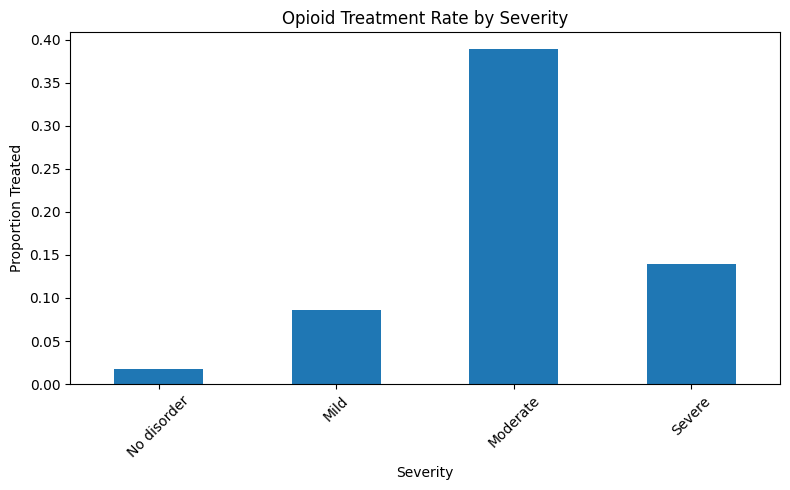

In [14]:
plt.figure(figsize=(8, 5))
treat_by_severity.plot(kind="bar")
plt.title("Opioid Treatment Rate by Severity")
plt.xlabel("Severity")
plt.ylabel("Proportion Treated")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Buprenorphine Indicator by Severity
This section examines how the buprenorphine-related indicator changes across severity groups.

In [15]:
df_opioid["RXBUPRANY2"].value_counts(normalize=True, dropna=False)

RXBUPRANY2
0.0    0.921630
1.0    0.064356
NaN    0.014014
Name: proportion, dtype: float64

In [16]:
bup_by_severity = pd.crosstab(
    df_opioid["SeverityLabel"],
    df_opioid["RXBUPRANY2"],
    normalize="index"
)[1.0]

bup_by_severity = bup_by_severity.reindex(["No disorder", "Mild", "Moderate", "Severe"])
bup_by_severity

SeverityLabel
No disorder    0.047176
Mild           0.147217
Moderate       0.497696
Severe         0.317568
Name: 1.0, dtype: float64

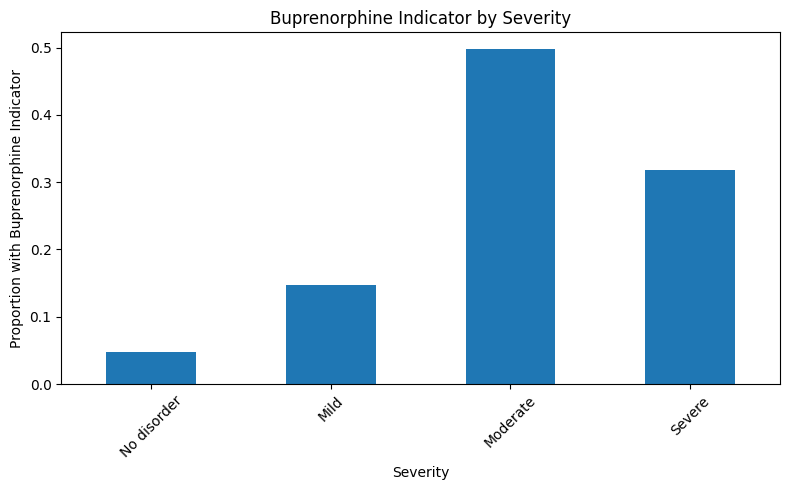

In [17]:
plt.figure(figsize=(8, 5))
bup_by_severity.plot(kind="bar")
plt.title("Buprenorphine Indicator by Severity")
plt.xlabel("Severity")
plt.ylabel("Proportion with Buprenorphine Indicator")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Methadone Indicator
This section summarizes the methadone-related indicator among past-year opioid users.

In [18]:
summary = {
    "metric": [
        "Past-year opioid users",
        "Opioid treatment rate",
        "Buprenorphine indicator rate",
        "Methadone indicator rate",
    ],
    "value": [
        len(df_opioid),
        df_opioid["SUTOPOPIPY2"].mean(),
        df_opioid["RXBUPRANY2"].dropna().mean(),
        df_opioid["RXMTDNANY2"].dropna().mean(),
    ]
}

summary_df = pd.DataFrame(summary)
summary_df

,metric,value
0,Past-year opioid users,10846.000000
1,Opioid treatment rate,0.029873
2,Buprenorphine indicator rate,0.065270
3,Methadone indicator rate,0.024331


## Key Findings
- The analysis identified 10,846 respondents with past-year opioid use.
- Most past-year opioid users fell into the "No disorder" category rather than mild, moderate, or severe opioid use disorder severity.
- Only a small fraction of past-year opioid users reported opioid-related treatment.
- Treatment rates increased with severity, but treatment remained incomplete even in the highest-severity group.
- Buprenorphine-related indicators also increased with severity, suggesting greater MAT exposure among more severe users.

## Limitations
- This analysis uses self-reported public survey data.
- Medication variables are indicators and may not fully capture formal MAT treatment history.
- The analysis is descriptive and cross-sectional, not causal.
- Exact dosage was not directly available in the selected variables, so severity was used instead.

## Conclusion
This analysis suggests that opioid-related treatment and medication exposure increase with disorder severity, but substantial treatment gaps remain, including among more severe opioid users.